<a href="https://colab.research.google.com/github/Arun-Varghese2312/Car-Price-Assignment-Module-4/blob/main/Car_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = "/content/drive/My Drive/Entri Assignments/Module 4/Car Price/CarPrice.csv"
df = pd.read_csv(file_path)

df.head()

Mounted at /content/drive


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
# Check dataset shape
df.shape

# Check column info
df.info()

# Statistical summary
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [ ]:
# Drop car_ID as it is not useful for prediction
df.drop(['car_ID'], axis=1, inplace=True)

In [ ]:
# Extract car company from CarName
df['company'] = df['CarName'].apply(lambda x: x.split(' ')[0])

# Drop original CarName column
df.drop('CarName', axis=1, inplace=True)

In [ ]:
# Convert categorical variables using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# Define features and target
X = df.drop('price', axis=1)
y = df['price']

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale only for SVR
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Import regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [ ]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR()
}

# Dictionary to store results
results = {}

# Train and predict
for name, model in models.items():
    if name == "SVR":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results[name] = y_pred

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Evaluate all models
for name, y_pred in results.items():
    print(f"\n{name}")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))


Linear Regression
R2 Score: 0.9163844104822618
MSE: 6600950.844753206
MAE: 1733.3904168808815

Decision Tree
R2 Score: 0.9010590122069003
MSE: 7810799.406192414
MAE: 1889.7764146341462

Random Forest
R2 Score: 0.9607695059611057
MSE: 3097012.9405257646
MAE: 1195.4056219512195

Gradient Boosting
R2 Score: 0.9271327814325037
MSE: 5752431.224035009
MAE: 1702.3218185682356

SVR
R2 Score: -0.10065553895816004
MSE: 86890173.84882385
MAE: 5701.439469615731


In [ ]:
# Train Random Forest for feature importance
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

# Get feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

# Display top 10 features
importance.head(10)

,0
enginesize,0.588323
curbweight,0.261654
highwaympg,0.053450
horsepower,0.028820
carwidth,0.011808
company_bmw,0.006618
wheelbase,0.006602
carlength,0.005657
peakrpm,0.005070
citympg,0.004705


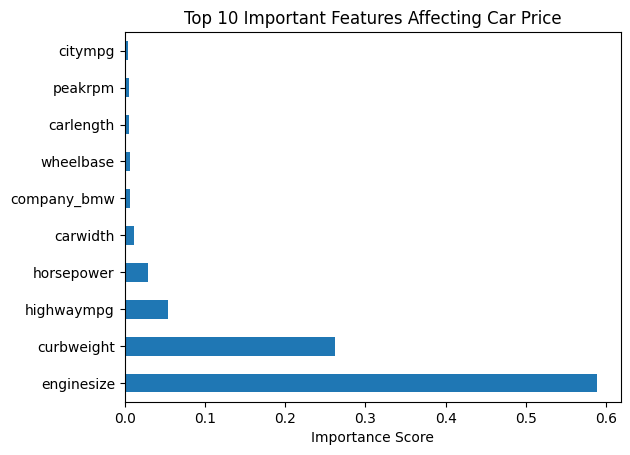

In [ ]:
import matplotlib.pyplot as plt

# Plot top features
importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features Affecting Car Price")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Grid Search
grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3, scoring='r2')
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
# Use best model
best_model = grid.best_estimator_

# Predictions
y_pred_tuned = best_model.predict(X_test)

# Evaluation
print("Tuned Model Performance:")
print("R2 Score:", r2_score(y_test, y_pred_tuned))
print("MSE:", mean_squared_error(y_test, y_pred_tuned))
print("MAE:", mean_absolute_error(y_test, y_pred_tuned))

Tuned Model Performance:
R2 Score: 0.9567206320998534
MSE: 3416647.323167565
MAE: 1272.3025936682404


In [ ]:
### Best Model

# #Random Forest Regressor is the best-performing model with the highest R² score (0.9608) and lowest error values among all models.
# It effectively captures non-linear relationships and provides robust predictions.

In [ ]:
### Hyperparameter Tuning Observation

# The tuned Random Forest model achieved an R² score of 0.9567, which is slightly lower than the base model's R² score of 0.9608. Additionally, MSE and MAE values increased after tuning.

# This indicates that hyperparameter tuning did not improve model performance in this case. The default Random Forest model was already well-optimized, and the chosen parameter grid may not have been ideal.

# Hence, the original Random Forest model remains the best-performing model.